In [1]:
import os
from pathlib import Path
from string import ascii_lowercase

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

if "MPL_STYLE" not in os.environ:
    os.environ["MPL_STYLE"] = "seaborn-v0_8-notebook"
plt.style.use(os.environ["MPL_STYLE"])


In [2]:
OUTPUT_BASE = Path(os.getenv("OUTPUT_BASE")).resolve(strict=True)

SUMMARY_DIR = OUTPUT_BASE / "summary" / "M6"
SUMMARY_CSV_PATH = (SUMMARY_DIR / "summary.csv").resolve(strict=True)
SCORE_CSV_PATH = (SUMMARY_DIR / "score.csv").resolve(strict=True)


In [3]:
summary_df = pd.read_csv(SUMMARY_CSV_PATH)
summary_df

,model_family,model_label,feature_set,target,n_star_per_sample,n_sample_per_snapshot,drop_probability,drop_ratio_min,drop_ratio_max,batch_size,...,snapshot_mean_phys_pearson_p,snapshot_mean_phys_spearman_r,snapshot_mean_phys_spearman_p,snapshot_mean_phys_se_mean,snapshot_mean_phys_se_median,snapshot_mean_phys_ae_median,snapshot_mean_phys_ae_q90,within_snapshot_phys_pred_std_mean,within_snapshot_phys_pred_std_q90,within_snapshot_phys_std_ae_corr
0,deep_sets,"DS[12,12]",Cartesian,age,128,16,0.6,0.1,0.9,10240,...,0.0,0.831752,0.0,-21.912935,-4.609742,15.440056,90.145642,0.110032,0.0,-0.105862
1,deep_sets,"DS[12,12]",Cartesian,total_mass,128,16,0.6,0.1,0.9,10240,...,0.0,0.473480,0.0,-7.362755,1.786265,10.209248,44.487217,0.074856,0.0,0.737476
2,deep_sets,"DS[12,12]",Cartesian+L,age,128,16,0.6,0.1,0.9,10240,...,0.0,0.834364,0.0,-19.314619,-2.774906,14.593137,87.333494,0.156361,0.0,-0.104501
3,deep_sets,"DS[12,12]",Cartesian+L,total_mass,128,16,0.6,0.1,0.9,10240,...,0.0,0.513117,0.0,-6.971878,1.562151,10.195225,43.140829,0.352180,0.0,0.691185
4,deep_sets,"DS[12,12]",Sky,age,128,16,0.6,0.1,0.9,10240,...,0.0,0.673092,0.0,-20.676089,-1.240990,23.639315,108.314772,0.162820,0.0,-0.053572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,summary_stats,SS[8],Cartesian+L,total_mass,128,16,0.6,0.1,0.9,10240,...,0.0,0.976087,0.0,-1.547363,0.695917,2.406770,13.450935,2.462154,0.0,0.675930
132,summary_stats,SS[8],Sky,age,128,16,0.6,0.1,0.9,10240,...,0.0,0.736937,0.0,-18.554924,0.317360,20.798212,101.605978,1.001758,0.0,-0.125090
133,summary_stats,SS[8],Sky,total_mass,128,16,0.6,0.1,0.9,10240,...,0.0,0.929431,0.0,-3.639768,0.335915,4.347089,19.962338,2.635286,0.0,0.704719
134,summary_stats,SS[8],Sky+L,age,128,16,0.6,0.1,0.9,10240,...,0.0,0.720095,0.0,-20.505752,-2.835735,22.478304,101.464424,1.118106,0.0,-0.139863


In [4]:
print(
    summary_df.columns,
    summary_df["model_family"].unique(),
    summary_df["feature_set"].unique(),
    summary_df["target"].unique(),
    sep="\n",
)

Index(['model_family', 'model_label', 'feature_set', 'target',
       'n_star_per_sample', 'n_sample_per_snapshot', 'drop_probability',
       'drop_ratio_min', 'drop_ratio_max', 'batch_size', 'learning_rate',
       'weight_decay', 'seed', 'auxiliary_label', 'experiment_name',
       'n_total_samples', 'n_snapshots', 'row_scaled_mae', 'row_scaled_rmse',
       'row_scaled_r2', 'row_scaled_ev', 'row_scaled_pearson_r',
       'row_scaled_pearson_p', 'row_scaled_spearman_r',
       'row_scaled_spearman_p', 'row_phys_mae', 'row_phys_rmse', 'row_phys_r2',
       'row_phys_ev', 'row_phys_pearson_r', 'row_phys_pearson_p',
       'row_phys_spearman_r', 'row_phys_spearman_p', 'snapshot_mean_phys_mae',
       'snapshot_mean_phys_rmse', 'snapshot_mean_phys_r2',
       'snapshot_mean_phys_ev', 'snapshot_mean_phys_pearson_r',
       'snapshot_mean_phys_pearson_p', 'snapshot_mean_phys_spearman_r',
       'snapshot_mean_phys_spearman_p', 'snapshot_mean_phys_se_mean',
       'snapshot_mean_phys_se_me

In [5]:
score_df = pd.read_csv(SCORE_CSV_PATH)
score_df

,model_label,Cartesian+L+age_snapshot_mean_phys_ae_median_score,Cartesian+L+age_snapshot_mean_phys_ae_q90_score,Cartesian+L+age_score,Cartesian+L+total_mass_snapshot_mean_phys_ae_median_score,Cartesian+L+total_mass_snapshot_mean_phys_ae_q90_score,Cartesian+L+total_mass_score,Cartesian+age_snapshot_mean_phys_ae_median_score,Cartesian+age_snapshot_mean_phys_ae_q90_score,Cartesian+age_score,...,Sky+L+total_mass_snapshot_mean_phys_ae_median_score,Sky+L+total_mass_snapshot_mean_phys_ae_q90_score,Sky+L+total_mass_score,Sky+age_snapshot_mean_phys_ae_median_score,Sky+age_snapshot_mean_phys_ae_q90_score,Sky+age_score,Sky+total_mass_snapshot_mean_phys_ae_median_score,Sky+total_mass_snapshot_mean_phys_ae_q90_score,Sky+total_mass_score,overall_score
0,"ST[6,6,1]",0.882353,1.000000,0.929412,0.529412,0.705882,0.600000,0.882353,0.647059,0.788235,...,0.588235,0.588235,0.588235,0.823529,0.882353,0.847059,0.764706,0.647059,0.717647,0.774510
1,SS[24],0.588235,0.882353,0.705882,0.941176,1.000000,0.964706,0.588235,0.823529,0.682353,...,0.941176,1.000000,0.964706,0.470588,0.470588,0.470588,0.882353,0.882353,0.882353,0.762745
2,"ST[6,2,2]",1.000000,0.705882,0.882353,0.352941,0.352941,0.352941,1.000000,1.000000,1.000000,...,0.529412,0.529412,0.529412,1.000000,0.941176,0.976471,0.588235,0.705882,0.635294,0.749020
3,"ST[6,3,2]",0.941176,0.823529,0.894118,0.764706,0.588235,0.694118,0.941176,0.882353,0.917647,...,0.647059,0.705882,0.670588,0.764706,1.000000,0.858824,0.411765,0.588235,0.482353,0.709804
4,"ST[4,4,2]",0.235294,0.529412,0.352941,0.588235,0.294118,0.470588,0.764706,0.941176,0.835294,...,0.705882,0.764706,0.729412,0.882353,0.529412,0.741176,0.647059,0.470588,0.576471,0.686275
5,SS[12],0.411765,0.470588,0.435294,1.000000,0.882353,0.952941,0.470588,0.529412,0.494118,...,1.000000,0.823529,0.929412,0.411765,0.411765,0.411765,0.941176,0.823529,0.894118,0.684314
6,"ST[6,3,1]",0.823529,0.764706,0.800000,0.470588,0.647059,0.541176,0.705882,0.705882,0.705882,...,0.764706,0.647059,0.717647,0.941176,0.823529,0.894118,0.352941,0.529412,0.423529,0.683333
7,SS[8],0.294118,0.411765,0.341176,0.882353,0.941176,0.905882,0.352941,0.470588,0.400000,...,0.823529,0.882353,0.847059,0.352941,0.352941,0.352941,1.000000,1.000000,1.000000,0.660784
8,"ST[6,2,1]",0.764706,0.941176,0.835294,0.294118,0.470588,0.364706,0.823529,0.588235,0.729412,...,0.470588,0.470588,0.470588,0.705882,0.705882,0.705882,0.529412,0.411765,0.482353,0.598039
9,SS[4],0.058824,0.058824,0.058824,0.823529,0.823529,0.823529,0.117647,0.294118,0.188235,...,0.882353,0.941176,0.905882,0.117647,0.176471,0.141176,0.823529,0.941176,0.870588,0.511765


In [6]:
print(
    score_df.columns,
)

Index(['model_label', 'Cartesian+L+age_snapshot_mean_phys_ae_median_score',
       'Cartesian+L+age_snapshot_mean_phys_ae_q90_score',
       'Cartesian+L+age_score',
       'Cartesian+L+total_mass_snapshot_mean_phys_ae_median_score',
       'Cartesian+L+total_mass_snapshot_mean_phys_ae_q90_score',
       'Cartesian+L+total_mass_score',
       'Cartesian+age_snapshot_mean_phys_ae_median_score',
       'Cartesian+age_snapshot_mean_phys_ae_q90_score', 'Cartesian+age_score',
       'Cartesian+total_mass_snapshot_mean_phys_ae_median_score',
       'Cartesian+total_mass_snapshot_mean_phys_ae_q90_score',
       'Cartesian+total_mass_score',
       'Sky+L+age_snapshot_mean_phys_ae_median_score',
       'Sky+L+age_snapshot_mean_phys_ae_q90_score', 'Sky+L+age_score',
       'Sky+L+total_mass_snapshot_mean_phys_ae_median_score',
       'Sky+L+total_mass_snapshot_mean_phys_ae_q90_score',
       'Sky+L+total_mass_score', 'Sky+age_snapshot_mean_phys_ae_median_score',
       'Sky+age_snapshot_mean_ph

In [7]:
MODEL_FAMILY = {
    "summary_stats": {
        "label": "Summary Stats",
        "label_short": "SS",
        "color": "#1f77b4",
        "marker": "o",
    },
    "deep_sets": {
        "label": "Deep Sets",
        "label_short": "DS",
        "color": "#d62728",
        "marker": "s",
    },
    "set_transformer": {
        "label": "Set Transformer",
        "label_short": "ST",
        "color": "#2ca02c",
        "marker": "^",
    },
}

FEATURE_SET_PLOT_CONFIG = {
    "Sky": {"label": "Sky", "color": "#1f77b4"},
    "Sky+L": {"label": "Sky$+L$", "color": "#6baed6"},
    "Cartesian": {"label": "Cartesian", "color": "#d62728"},
    "Cartesian+L": {"label": "Cartesian$+L$", "color": "#fb6a4a"},
}

TARGET_PLOT_CONFIG = {
    "age": {"label": "Age", "unit": "Myr"},
    "total_mass": {"label": "Total Mass", "unit": "$M_\\odot$"},
}

## Visualization

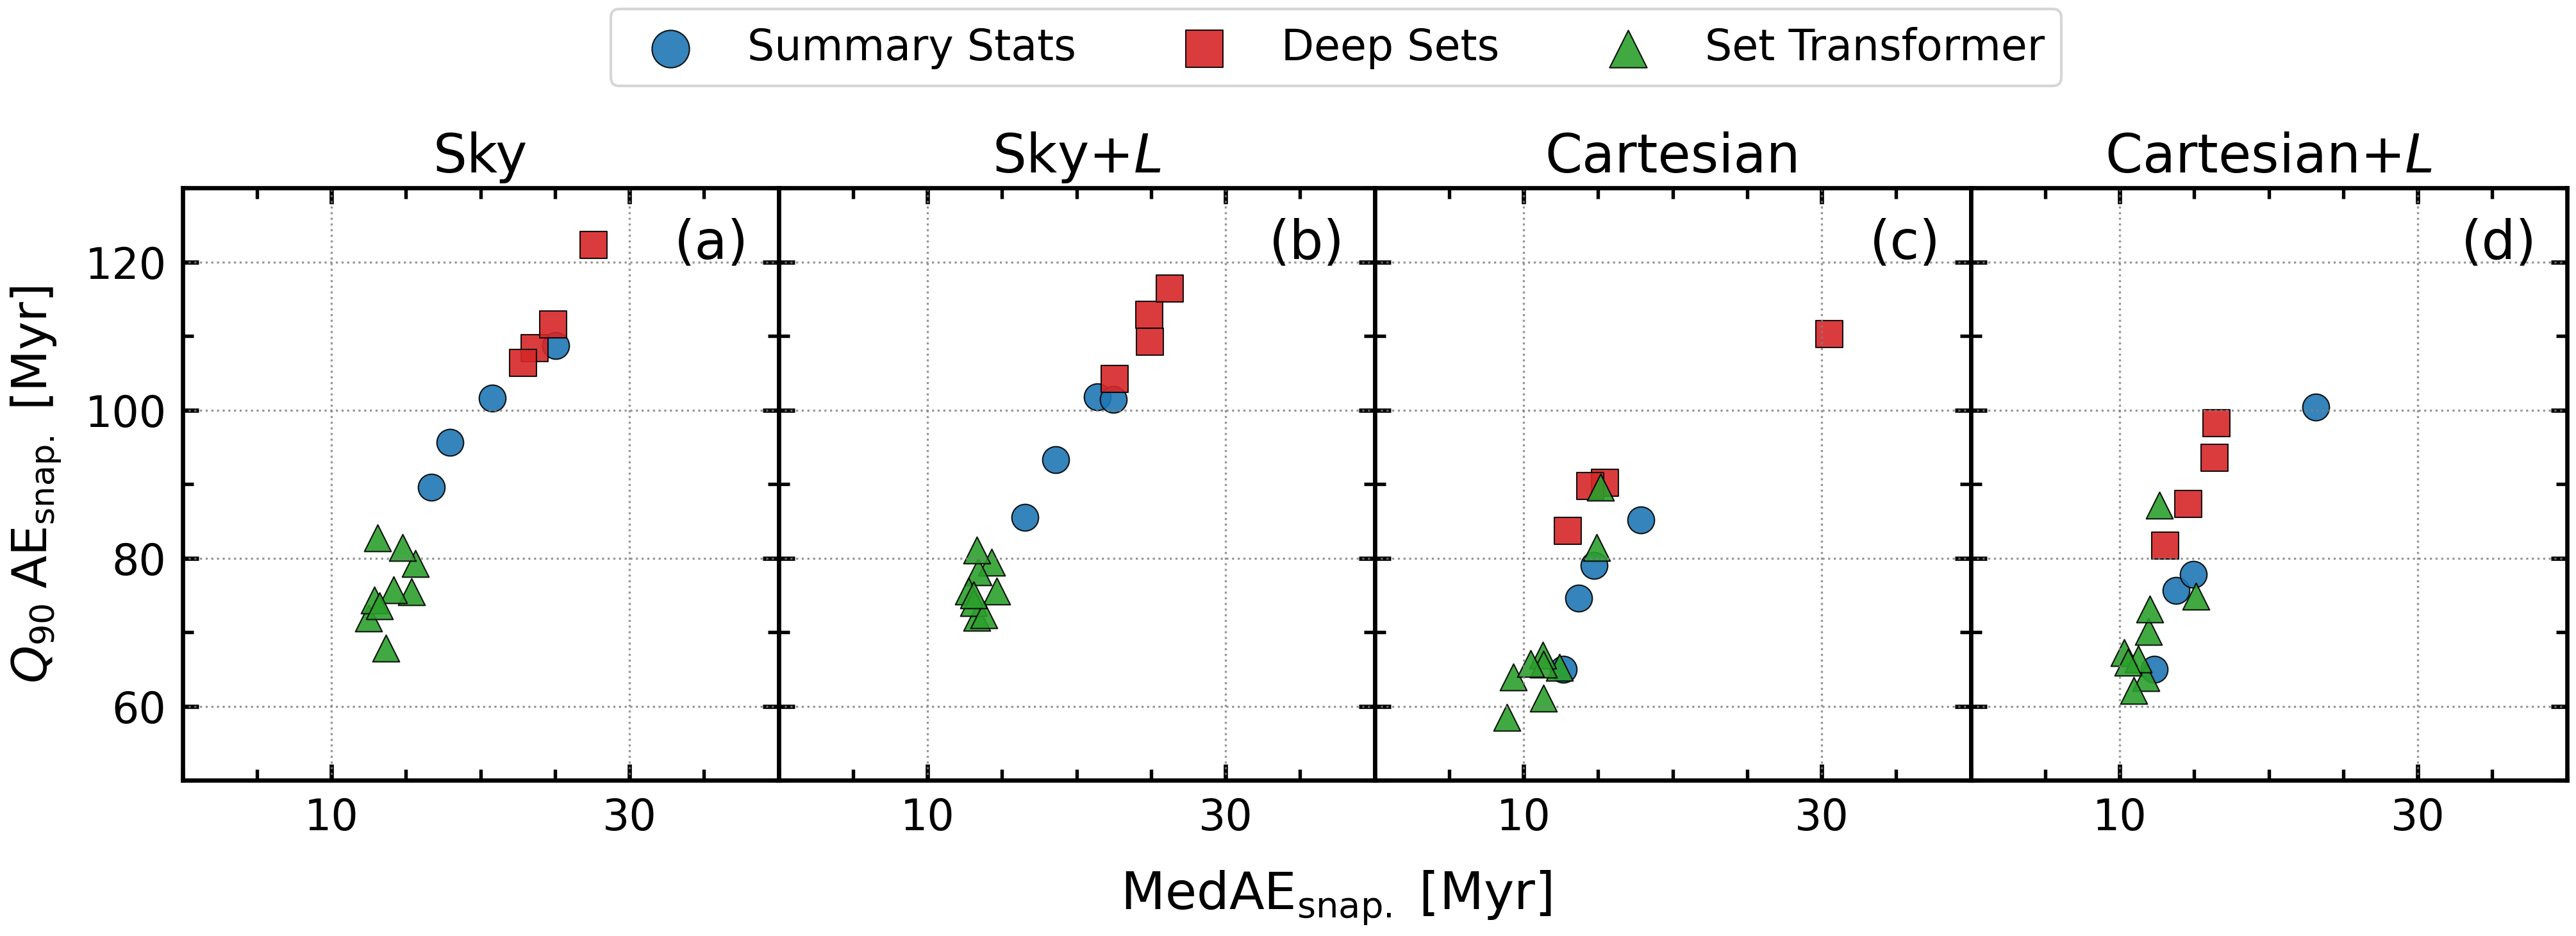

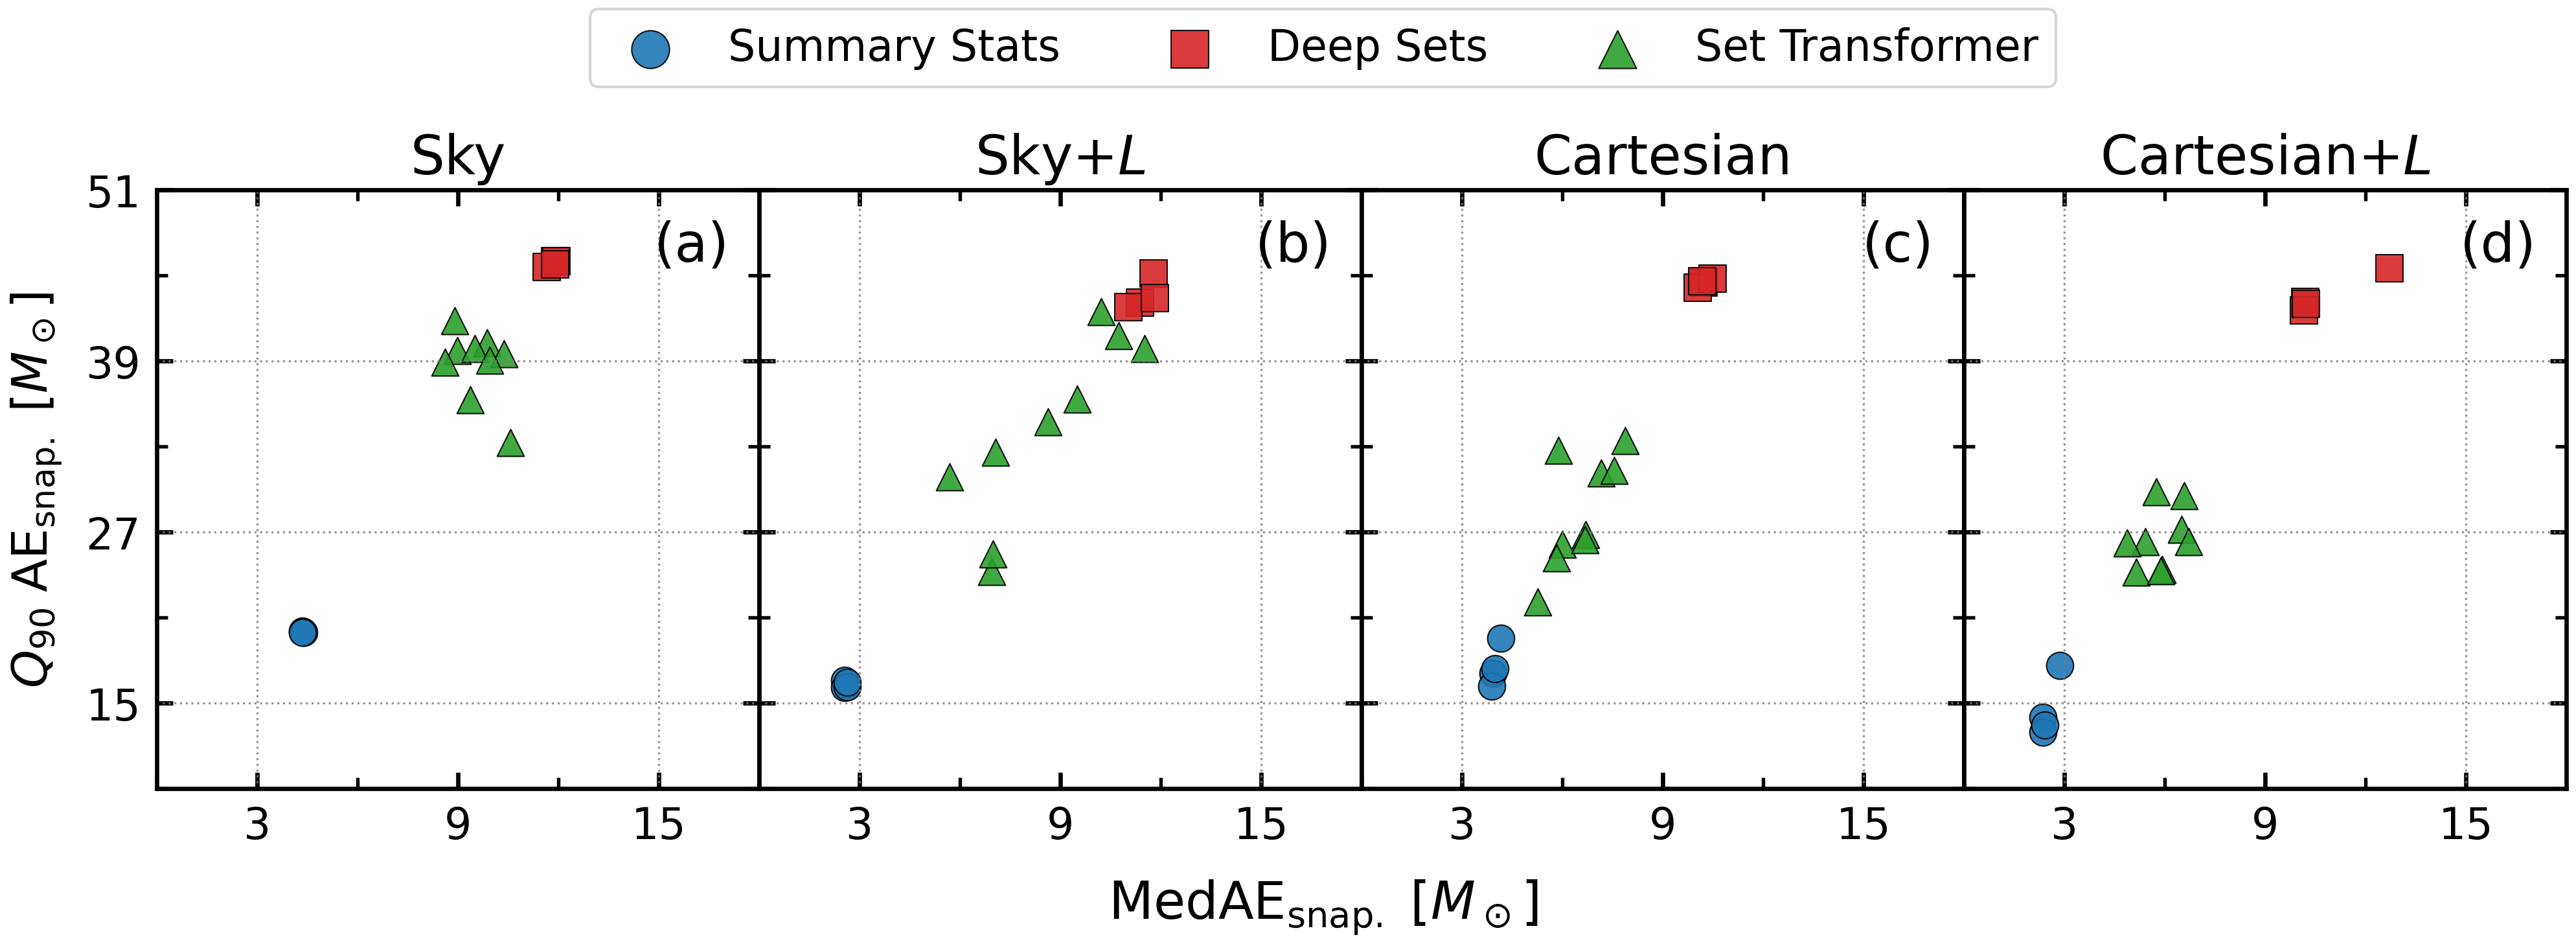

In [8]:
for target_label, plot_config in TARGET_PLOT_CONFIG.items():
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), dpi=300, gridspec_kw={"wspace": 0})

    target_df = summary_df[summary_df["target"] == target_label].copy()

    for ax_idx, (ax, feature_set_label) in enumerate(zip(axs, FEATURE_SET_PLOT_CONFIG)):
        feature_df = target_df[target_df["feature_set"] == feature_set_label]

        ax.set_title(FEATURE_SET_PLOT_CONFIG[feature_set_label]["label"], fontsize=20)
        ax.text(
            0.95,
            0.95,
            f"({ascii_lowercase[ax_idx]})",
            transform=ax.transAxes,
            va="top",
            ha="right",
            fontsize=20,
        )

        for model_family, family_cfg in MODEL_FAMILY.items():
            model_df = feature_df[feature_df["model_family"] == model_family]

            ax.scatter(
                model_df["snapshot_mean_phys_ae_median"],
                model_df["snapshot_mean_phys_ae_q90"],
                s=100,
                c=family_cfg["color"],
                marker=family_cfg["marker"],
                alpha=0.9,
                label=family_cfg["label"],
                edgecolors="black",
                linewidths=0.5,
            )

        ax_line_cfg = {"ls": ":", "lw": 0.8, "c": "gray", "alpha": 0.8}
        if target_label == "age":
            ax.set_xlim(0, 40)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20, offset=10))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(5))
            ax.set_ylim(50, 130)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
            ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(10))
            [ax.axhline(y, **ax_line_cfg) for y in [60, 80, 100, 120]]
            [ax.axvline(x, **ax_line_cfg) for x in [10, 30]]
        else:
            ax.set_xlim(0, 18)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(6, offset=3))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(3))
            ax.set_ylim(9, 51)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(12, offset=3))
            ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(6, offset=3))
            [ax.axhline(y, **ax_line_cfg) for y in [15, 27, 39]]
            [ax.axvline(x, **ax_line_cfg) for x in [3, 15]]

        if ax in axs[1:]:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(
                r"$Q_{90}\;\mathrm{AE}_\mathrm{snap.}$" + f" [{plot_config['unit']}]"
            )

    legend_entries = {
        label: handle
        for legend_ax in axs
        for handle, label in zip(*legend_ax.get_legend_handles_labels())
    }

    fig.supxlabel(
        r"$\mathrm{MedAE}_\mathrm{snap.}$" + f" [{plot_config['unit']}]", y=-0.08
    )
    fig.legend(
        list(legend_entries.values()),
        list(legend_entries.keys()),
        loc="upper center",
        ncol=4,
        markerscale=1.4,
        frameon=True,
        bbox_to_anchor=(0.5, 1.14),
    )

    fig.savefig(SUMMARY_DIR / f"analysis-{target_label}.pdf", bbox_inches="tight")


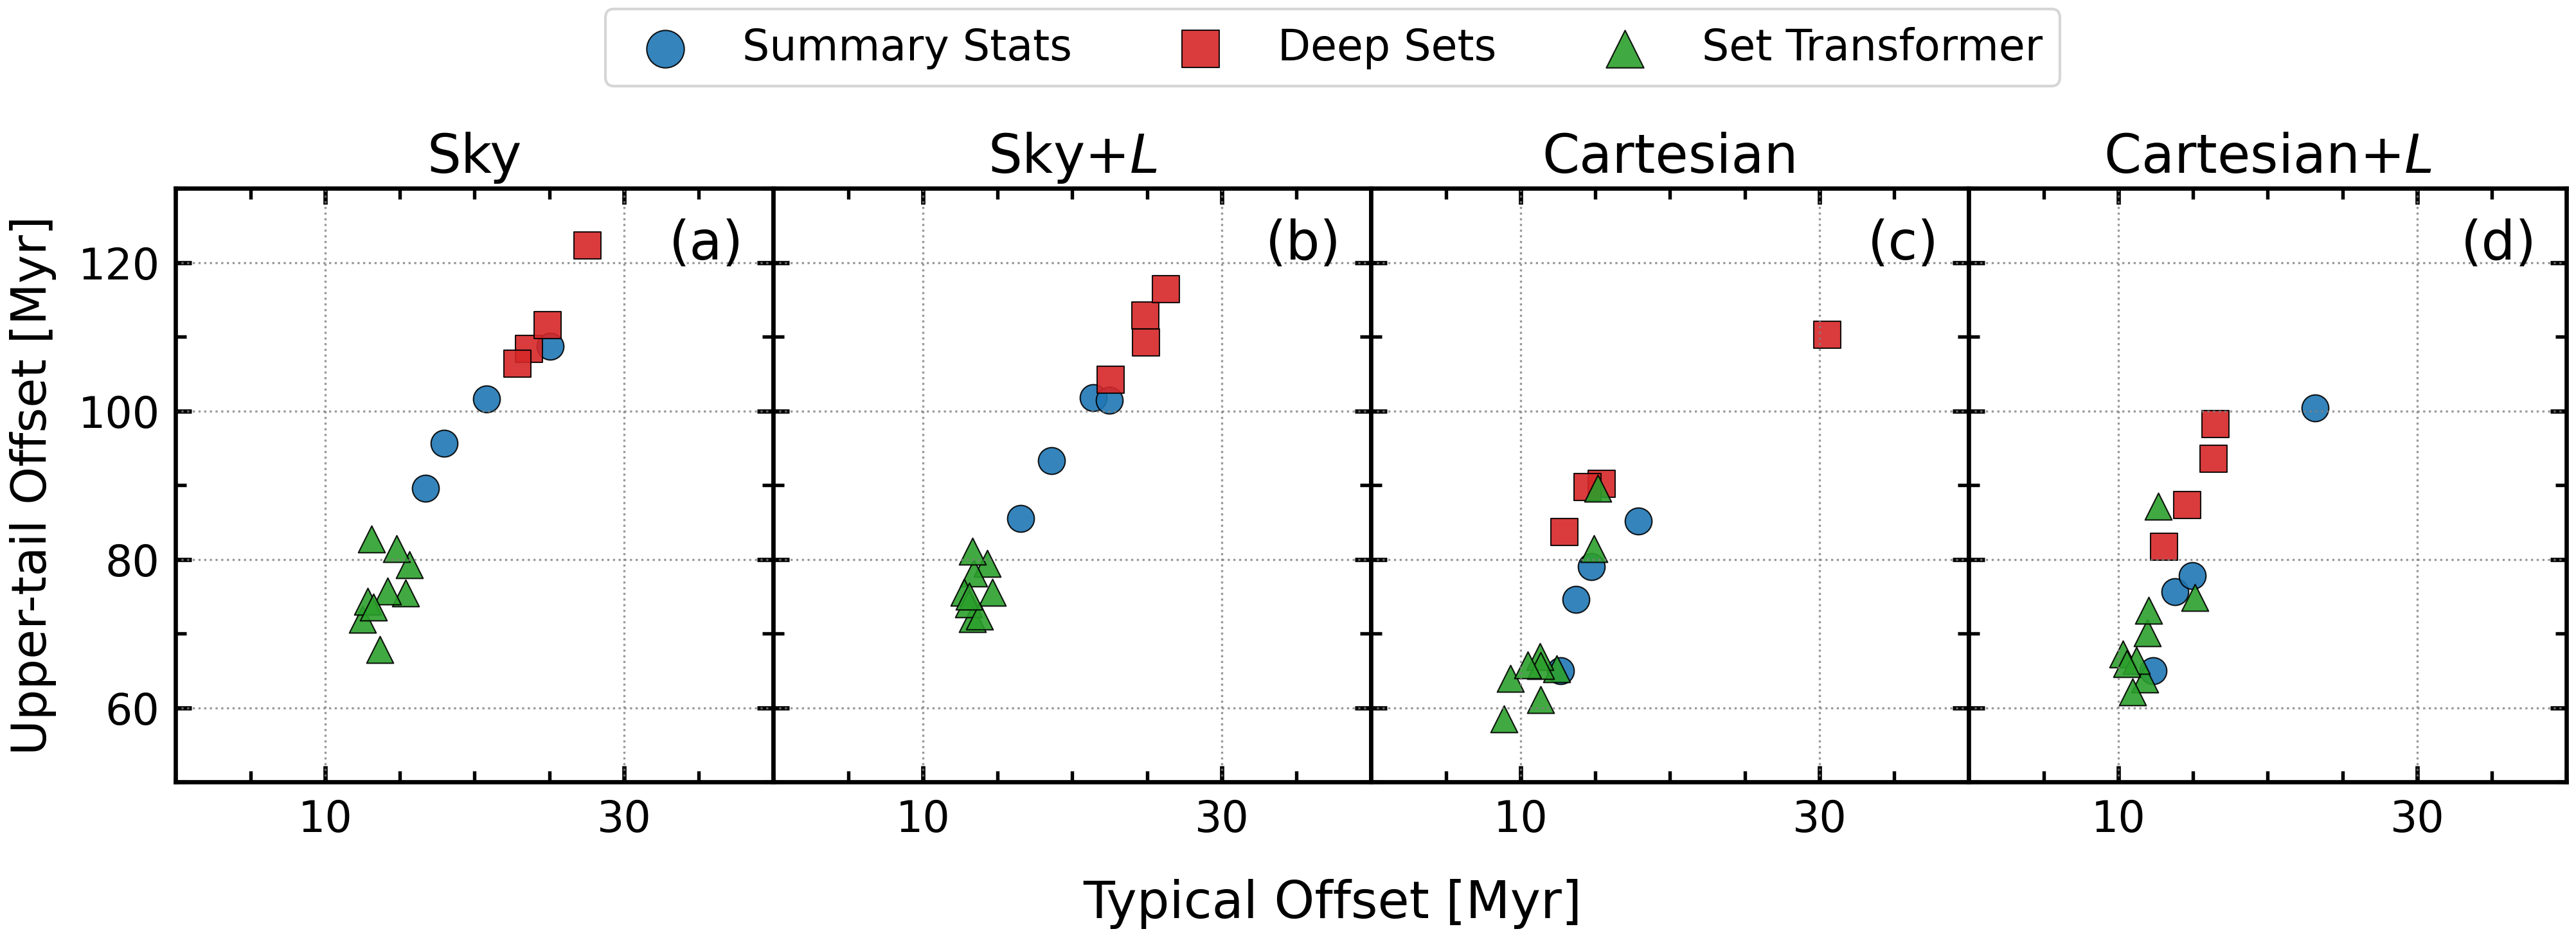

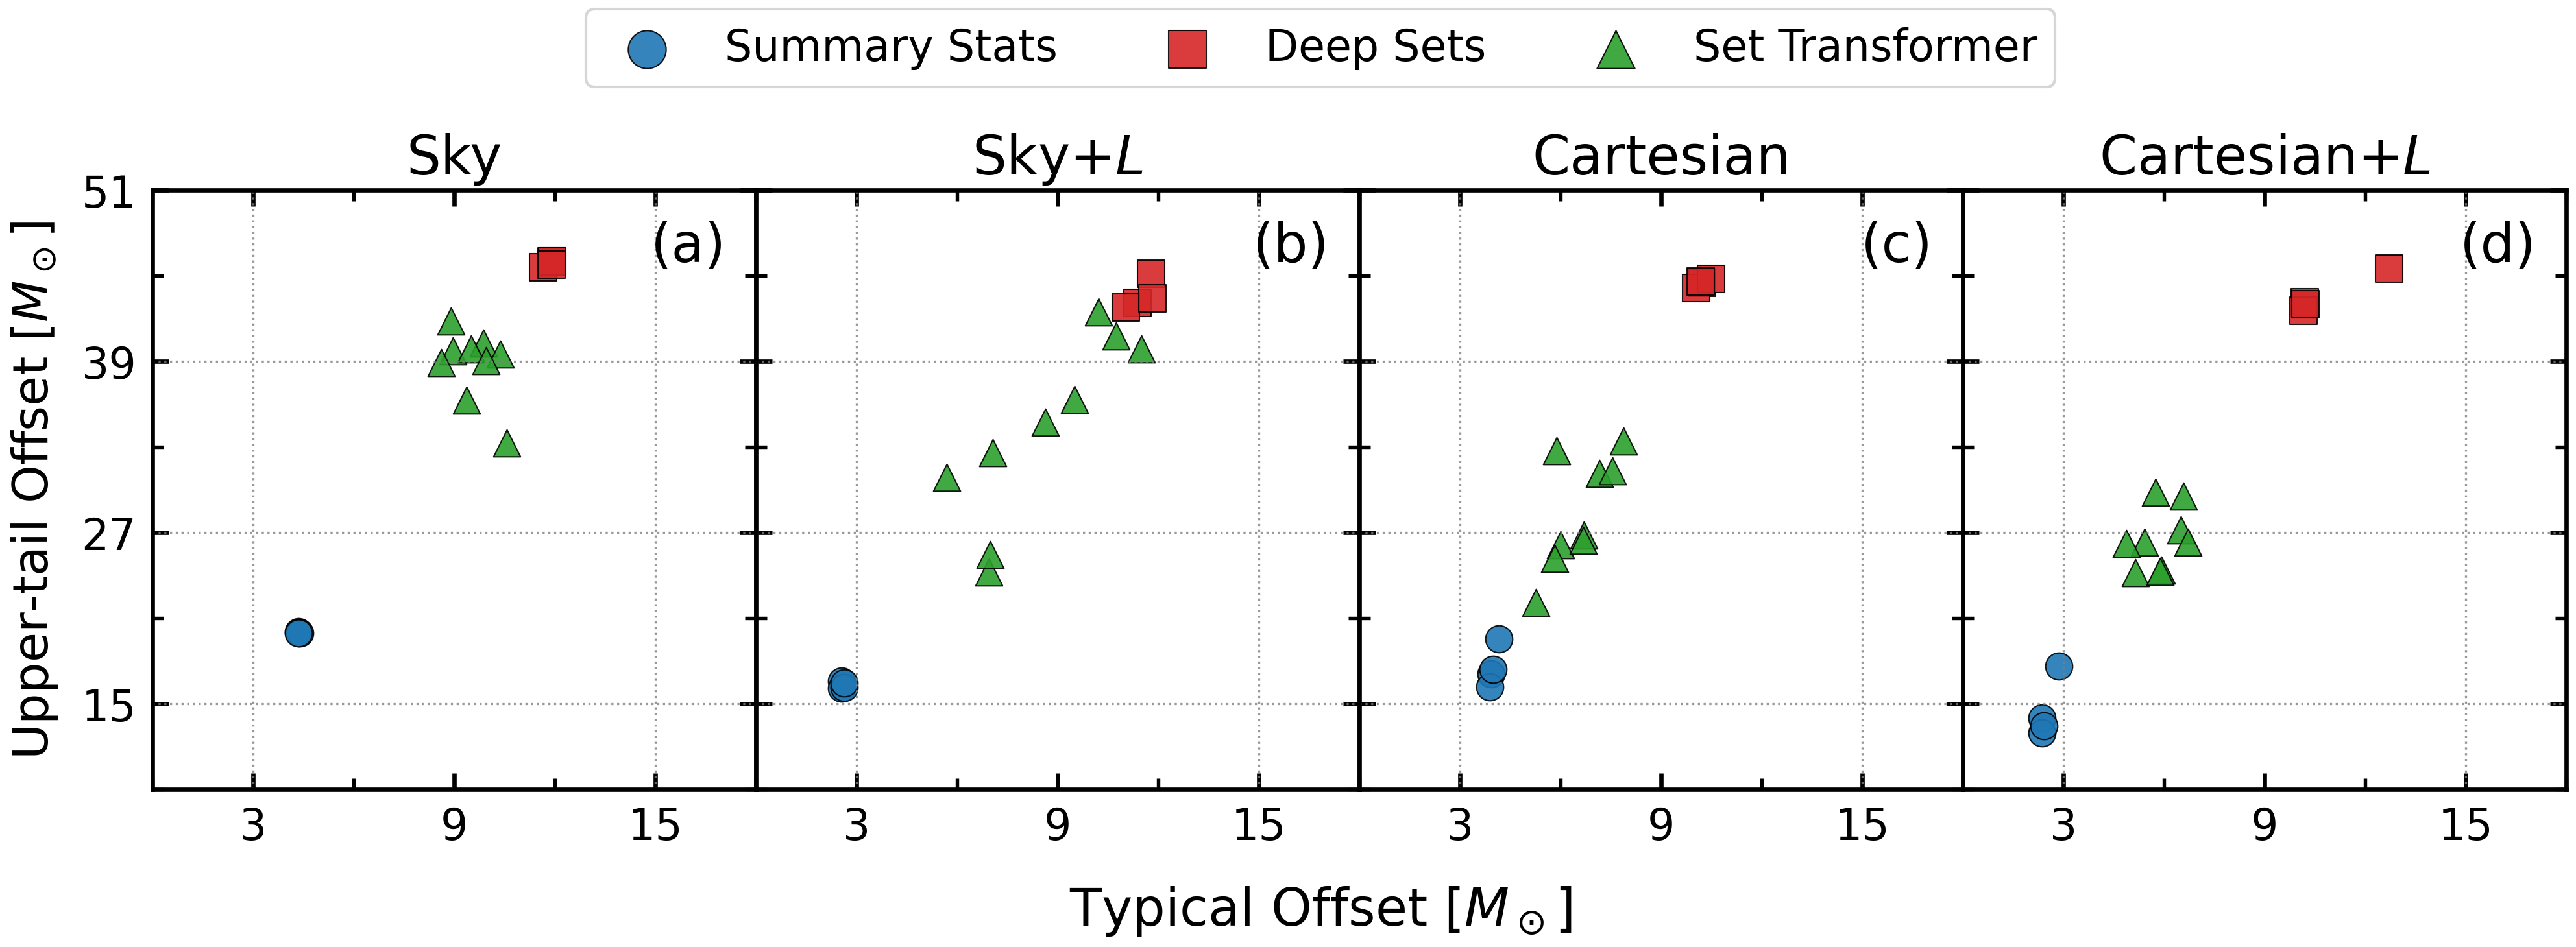

In [9]:
for target_label, plot_config in TARGET_PLOT_CONFIG.items():
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), dpi=300, gridspec_kw={"wspace": 0})

    target_df = summary_df[summary_df["target"] == target_label].copy()

    for ax_idx, (ax, feature_set_label) in enumerate(zip(axs, FEATURE_SET_PLOT_CONFIG)):
        feature_df = target_df[target_df["feature_set"] == feature_set_label]

        ax.set_title(FEATURE_SET_PLOT_CONFIG[feature_set_label]["label"], fontsize=20)
        ax.text(
            0.95,
            0.95,
            f"({ascii_lowercase[ax_idx]})",
            transform=ax.transAxes,
            va="top",
            ha="right",
            fontsize=20,
        )

        for model_family, family_cfg in MODEL_FAMILY.items():
            model_df = feature_df[feature_df["model_family"] == model_family]

            ax.scatter(
                model_df["snapshot_mean_phys_ae_median"],
                model_df["snapshot_mean_phys_ae_q90"],
                s=100,
                c=family_cfg["color"],
                marker=family_cfg["marker"],
                alpha=0.9,
                label=family_cfg["label"],
                edgecolors="black",
                linewidths=0.5,
            )

        ax_line_cfg = {"ls": ":", "lw": 0.8, "c": "gray", "alpha": 0.8}
        if target_label == "age":
            ax.set_xlim(0, 40)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20, offset=10))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(5))
            ax.set_ylim(50, 130)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
            ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(10))
            [ax.axhline(y, **ax_line_cfg) for y in [60, 80, 100, 120]]
            [ax.axvline(x, **ax_line_cfg) for x in [10, 30]]
        else:
            ax.set_xlim(0, 18)
            ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(6, offset=3))
            ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(3))
            ax.set_ylim(9, 51)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(12, offset=3))
            ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(6, offset=3))
            [ax.axhline(y, **ax_line_cfg) for y in [15, 27, 39]]
            [ax.axvline(x, **ax_line_cfg) for x in [3, 15]]

        if ax in axs[1:]:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(
                # r"$Q_{90}\;\mathrm{AE}_\mathrm{snap.}$" + f" [{plot_config['unit']}]"
                r"Upper-tail Offset" + f" [{plot_config['unit']}]"
            )

    legend_entries = {
        label: handle
        for legend_ax in axs
        for handle, label in zip(*legend_ax.get_legend_handles_labels())
    }

    fig.supxlabel(
        # r"$\mathrm{MedAE}_\mathrm{snap.}$" + f" [{plot_config['unit']}]", y=-0.08
        r"Typical Offset" + f" [{plot_config['unit']}]", y=-0.08
    )
    fig.legend(
        list(legend_entries.values()),
        list(legend_entries.keys()),
        loc="upper center",
        ncol=4,
        markerscale=1.4,
        frameon=True,
        bbox_to_anchor=(0.5, 1.14),
    )

    fig.savefig(SUMMARY_DIR / f"mod-analysis-{target_label}.pdf", bbox_inches="tight")
